In [1]:
%load_ext autoreload
%autoreload 2

In [61]:
import numpy as np
import csv 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import ConfusionMatrixDisplay
import umap
from plotting import save_plot_scatter, save_confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd



In [16]:
# Load data
X = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/train_in - Copy.csv', delimiter=',')
y = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/train_out - Copy.csv', delimiter=',').ravel().astype(int)
X_test = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/test_in - Copy.csv', delimiter=',')
y_test = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/test_out - Copy.csv', delimiter=',').astype(int)


### Task 1.1

In [8]:
unique_labels = np.unique(y)
means = np.array([X[y == label].mean(axis=0) for label in unique_labels])

n_labels = unique_labels.shape[0]
dist_matrix = []
for i in range(n_labels):
    dist_row = []
    for j in range(n_labels):
        euclidean_dist = np.linalg.norm(means[i]-means[j])
        dist_row.append(euclidean_dist)
    dist_matrix.append(dist_row)
dist_matrix = np.array(dist_matrix)
np.set_printoptions(precision=2, suppress=True, linewidth=100) # Comment out to print normally
print(dist_matrix) # Uncomment to check matrix

[[ 0.   14.45  9.33  9.14 10.77  7.52  8.15 11.86  9.91 11.49]
 [14.45  0.   10.13 11.73 10.17 11.12 10.61 10.74 10.09  9.93]
 [ 9.33 10.13  0.    8.18  7.93  7.91  7.33  8.87  7.08  8.89]
 [ 9.14 11.73  8.18  0.    9.09  6.12  9.3   8.92  7.02  8.35]
 [10.77 10.17  7.93  9.09  0.    8.    8.78  7.58  7.38  6.01]
 [ 7.52 11.12  7.91  6.12  8.    0.    6.7   9.21  6.97  8.26]
 [ 8.15 10.61  7.33  9.3   8.78  6.7   0.   10.89  8.59 10.44]
 [11.86 10.74  8.87  8.92  7.58  9.21 10.89  0.    8.47  5.43]
 [ 9.91 10.09  7.08  7.02  7.38  6.97  8.59  8.47  0.    6.4 ]
 [11.49  9.93  8.89  8.35  6.01  8.26 10.44  5.43  6.4   0.  ]]


### Task 1.2

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(X_pca.shape)
plot_scatter(X_pca, y, "pca_plot.png")

X_tsne = TSNE(n_components=2).fit_transform(X)
print(X_tsne.shape)
plot_scatter(X_tsne, y, "tsne_plot.png")

reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)
print(X_umap.shape)
plot_scatter(X_umap, y, "umap_plot.png")

# plot PCA centres
X_pca_centres = pca.fit_transform(means)
plot_scatter(X_pca_centres, unique_labels, "pca_centres_plot.png")

### Task 1.3

In [9]:
def centre_predictions(string, X, y):
    """
    uses euclidean distance from label means to predict class
    """
    predictions = []
    losses = []
    for idx, x_i in enumerate(X):
        x_i_broadcasted = np.broadcast_to(x_i, means.shape)
        dist = np.linalg.norm(x_i_broadcasted-means, axis=1)
        pred_y = np.argmin(dist)
        loss = 1 if pred_y == y[idx] else 0
        predictions.append(pred_y)
        losses.append(loss)

    percentage_true_pred = np.sum(losses) / len(losses)
    print (string, f"Percentage of true predictions: {percentage_true_pred:.4f}")

    return predictions, losses

train_centre_pred, _ = centre_predictions("(train)",X, y)

test_centre_pred, _ = centre_predictions("(test)", X_test, y_test)

(train) Percentage of true predictions: 0.8635
(test) Percentage of true predictions: 0.8040


### Task 1.4

In [11]:
neigh = KNeighborsClassifier()
neigh.fit(X,y)

train_pred, test_pred = neigh.predict(X), neigh.predict(X_test)

print(X.shape, train_pred.shape)
train_loss_arr = np.where(train_pred == y, 1, 0)
test_loss_arr = np.where(test_pred == y_test, 1, 0)

def print_pred_perc(string, losses):
    percentage_true_pred = np.sum(losses) / len(losses)
    print (string, f"Percentage of true predictions: {percentage_true_pred:.4f}")

print_pred_perc("(train)", train_loss_arr)
print_pred_perc("(test)", test_loss_arr)

# Confusion matrices

print("Shapes:", len(train_centre_pred), y.shape)

save_confusion_matrix(train_centre_pred, y, "cm_centre_pred_train.png", "Confusion Matrix: using train label centres (train).")
save_confusion_matrix(test_centre_pred, y_test, "cm_centre_pred_test.png", "Confusion Matrix: using train label centres (test).")
save_confusion_matrix(train_pred, y, "cm_knn_pred_train.png", "Confusion Matrix: using knn with train labels (train).")
save_confusion_matrix(test_pred, y_test, "cm_knn_pred_test.png", "Confusion Matrix: using knn with train labels (test).")

(1707, 256) (1707,)
(train) Percentage of true predictions: 0.9660
(test) Percentage of true predictions: 0.9080
Shapes: 1707 (1707,)


## Task 2

Epoch 1 | Avg loss: 2.268531
Epoch 2 | Avg loss: 369.585511
Epoch 3 | Avg loss: 975.788155
Epoch 4 | Avg loss: 939.411863
Epoch 5 | Avg loss: 412.511872
Epoch 6 | Avg loss: 354.680783
Epoch 7 | Avg loss: 216.526319
Epoch 8 | Avg loss: 170.162140
Epoch 9 | Avg loss: 127.992989
Epoch 10 | Avg loss: 63.234421
(Test) | Avg loss: 86.718506| Accuracy: 0.756000
Epoch 1 | Avg loss: 2.297567
Epoch 2 | Avg loss: 345.423940
Epoch 3 | Avg loss: 915.495719
Epoch 4 | Avg loss: 906.789921
Epoch 5 | Avg loss: 589.946555
Epoch 6 | Avg loss: 556.738076
Epoch 7 | Avg loss: 403.954060
Epoch 8 | Avg loss: 285.986658
Epoch 9 | Avg loss: 167.908596
Epoch 10 | Avg loss: 123.242528
(Test) | Avg loss: 121.761474| Accuracy: 0.755000
Epoch 1 | Avg loss: 2.368961
Epoch 2 | Avg loss: 456.747597
Epoch 3 | Avg loss: 915.058730
Epoch 4 | Avg loss: 918.909015
Epoch 5 | Avg loss: 588.548249
Epoch 6 | Avg loss: 593.112129
Epoch 7 | Avg loss: 446.130047
Epoch 8 | Avg loss: 233.829853
Epoch 9 | Avg loss: 177.801303
Epoch 1

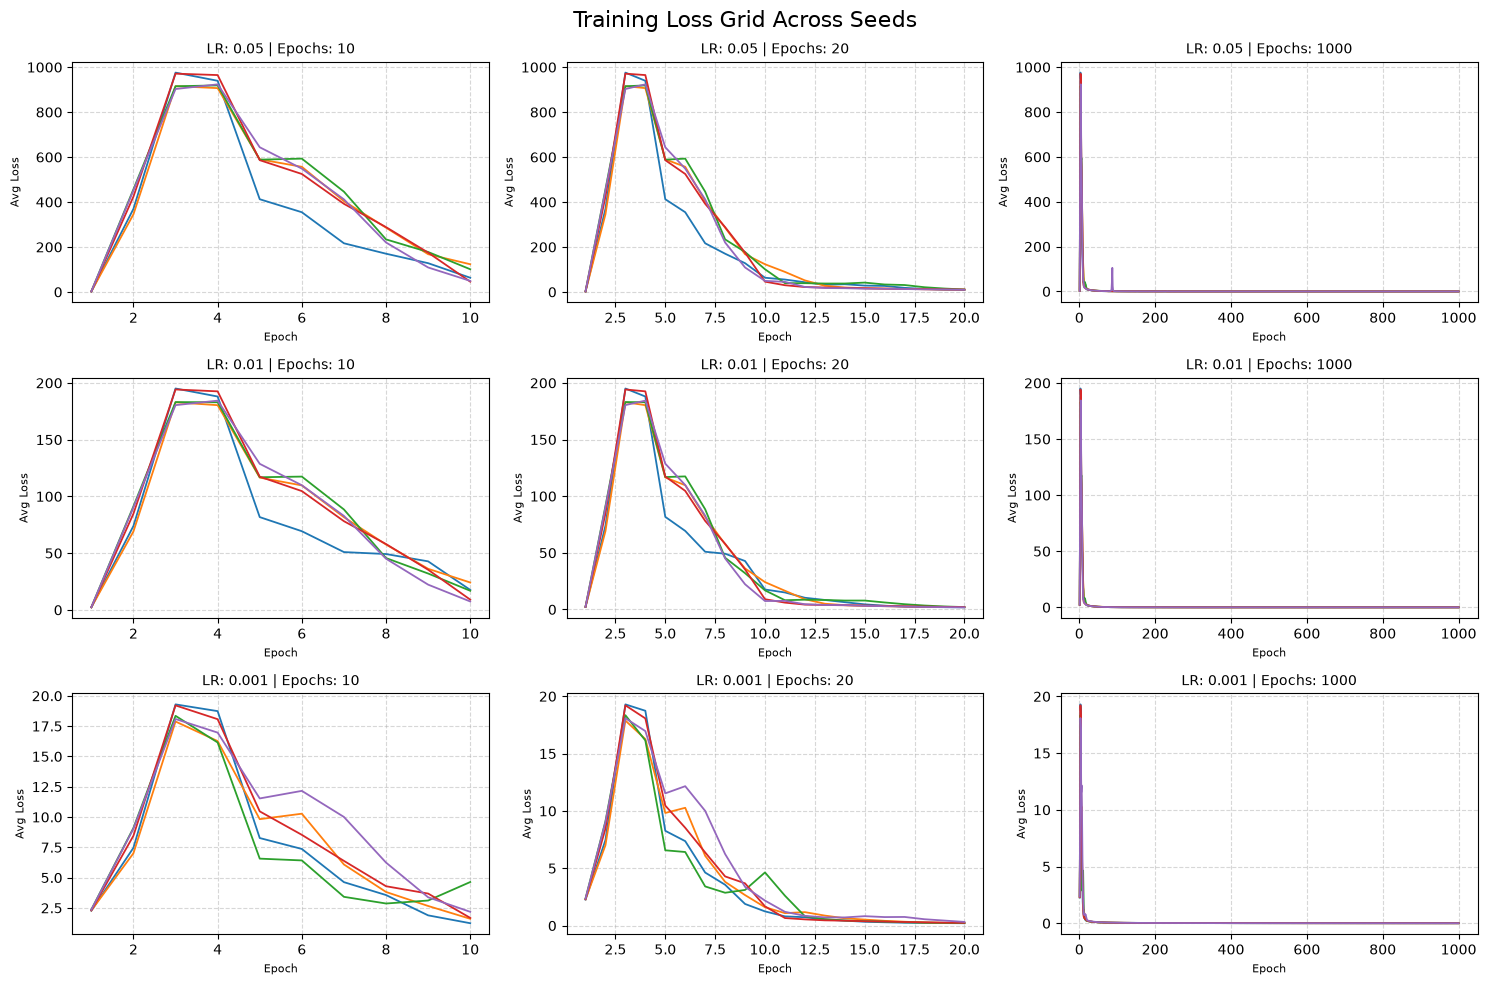

In [64]:
seeds = [11, 33, 99, 297, 891]
lrs = [0.05, 0.01,0.001]
epochs = [10, 20, 1000]

def run_experiment(seeds, lrs, epochs):
    experiment_logs= []
    figs, axes = plt.subplots(
        nrows=len(lrs),
        ncols=len(epochs),
        figsize=(15,10),
        sharex=False,
        sharey=False,
    )
    figs.suptitle(
        f"Training Loss Grid Across Seeds", fontsize=16
    )
    for idx_lr, lr in enumerate(lrs):
        for idx_n_epochs, n_epochs in enumerate(epochs):    
            ax = axes[idx_lr, idx_n_epochs]

            for _, seed in enumerate(seeds):
                np.random.seed(seed)                       

                X_in = X.T 
                in_dim = X_in.shape[0]
                n_samples = X_in.shape[1]
                bias = np.ones((1, n_samples))
                T = np.vstack((bias, X_in))
                out_dim = 10
                variance_W = 4 / (in_dim + out_dim)
                W = np.hstack((np.zeros((out_dim, 1)), np.random.normal(0, variance_W, (out_dim, in_dim))))

                loss = []

                for i in range(n_epochs):
                    f = W @ T #logit outputs
                    f_max = np.max(f, axis=0)
                    exp_f = np.exp(f - f_max) # prevent overflow
                    log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
                    target_logits = f[y, np.arange(f.shape[1])]
                    L = -np.sum(target_logits - log_sum_exp) #mutliclass cross entropy loss computation

                    loss.append(L)
                    print(f"Epoch {i+1} | Avg loss: {L / n_samples:.6f}")

                    prob = exp_f / np.sum(exp_f, axis=0)
                    prob[y, np.arange(f.shape[1])] -= 1.0
                    dW = prob @ T.T
                    W = W - lr*dW
            
                predictions = np.argmax(f, axis=0)
                accuracy = np.sum((predictions == y).astype(int))/y.shape[0]

                experiment_log = {
                    "seed": seed,
                    "epochs": n_epochs,
                    "lr": lr,
                    "avg_train_loss": L / n_samples,
                    "train_accuracy": accuracy
                }

                T = np.vstack((np.ones((1, y_test.shape[0])), X_test.T))
                predictions = np.argmax(W @ T, axis=0)

                f = W @ T #logit outputs
                f_max = np.max(f, axis=0)
                exp_f = np.exp(f - f_max) # prevent overflow
                log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
                target_logits = f[y_test, np.arange(f.shape[1])]
                L = -np.sum(target_logits - log_sum_exp) #mutliclass cross entropy loss computation
                accuracy = np.sum((predictions == y_test).astype(int))/y_test.shape[0]
                print(f"(Test) | Avg loss: {L / y_test.shape[0]:.6f}| Accuracy: {accuracy:.6f}")

                experiment_log["test_loss"] = L / L / y_test.shape[0]
                experiment_log["test_accuracy"] = accuracy
                experiment_logs.append(experiment_log)

                avg_losses = [l / n_samples for l in loss]
                ax.plot(range(1, n_epochs + 1), avg_losses, linewidth=1.3, label=f"Seed: {seed}")
            ax.set_title(f"LR: {lr} | Epochs: {n_epochs}", fontsize=10)
            ax.set_xlabel("Epoch", fontsize=8)
            ax.set_ylabel("Avg Loss", fontsize=8)
            ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"grid_loss_combined_seeds.png")
    plt.show()

    filename = f"experiment_a1.csv"

    df = pd.DataFrame(experiment_logs) 
    df.to_csv(filename, index=False)
    

run_experiment(seeds, lrs, epochs)

In [39]:
y_test.shape

(1000,)

In [23]:
prob

NameError: name 'prob' is not defined

In [22]:
f_max

array([[0.32479564, 0.28858313, 0.32085901, ..., 0.27060625, 0.07764201,
        0.16316173]], shape=(1, 1707))

In [14]:
target_logits = f[y.astype(int), np.arange(f.shape[1])]

In [15]:
target_logits

array([-0.01810218, -0.35088227, -0.13141933, ..., -0.37869136,
        0.07764201,  0.0815978 ], shape=(1707,))

In [110]:
y.size

1707

In [122]:
y_binary = -np.ones((out_dim, y.size), dtype=np.int8)
# y_binary[np.arange(y.size), y] = 1
y_binary[y.astype(int), np.arange(y.size)] = 1
y_binary

array([[-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ...,  1, -1, -1],
       [-1, -1, -1, ..., -1, -1,  1],
       [-1, -1, -1, ..., -1,  1, -1]], shape=(10, 1707), dtype=int8)

In [ ]:

np.full(10, -1)

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [71]:
a = np.array([1,2,1])
np.tile(a, (3,1))

array([[1, 2, 1],
       [1, 2, 1],
       [1, 2, 1]])